# Rebar YOLO26L Segmentation Visualization

This notebook visualizes the trained `yolo26l_sam3_rebar_v1` run and overlays predicted masks on the validation images.

In [31]:
from pathlib import Path
import os

ROOT = Path.cwd()
if ROOT.name == "rebar-segementation-yolo26":
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from IPython.display import display
from PIL import Image
from ultralytics import YOLO

RUN_DIR = ROOT / "rebar-segementation-yolo26" / "yolo26l_sam3_rebar_v1"
MODEL_PATH = RUN_DIR / "weights" / "best.pt"
RESULTS_IMAGE = RUN_DIR / "results.png"
DATA_YAML = ROOT / "datasets" / "sam3_annotation_without_open_source_rebar_v1" / "data.yaml"
VALID_IMAGES = ROOT / "datasets" / "sam3_annotation_without_open_source_rebar_v1" / "valid" / "images"

for path in [RUN_DIR, MODEL_PATH, RESULTS_IMAGE, DATA_YAML, VALID_IMAGES]:
    if not path.exists():
        raise FileNotFoundError(path)

image_paths = sorted(p for p in VALID_IMAGES.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})

## Training Curves

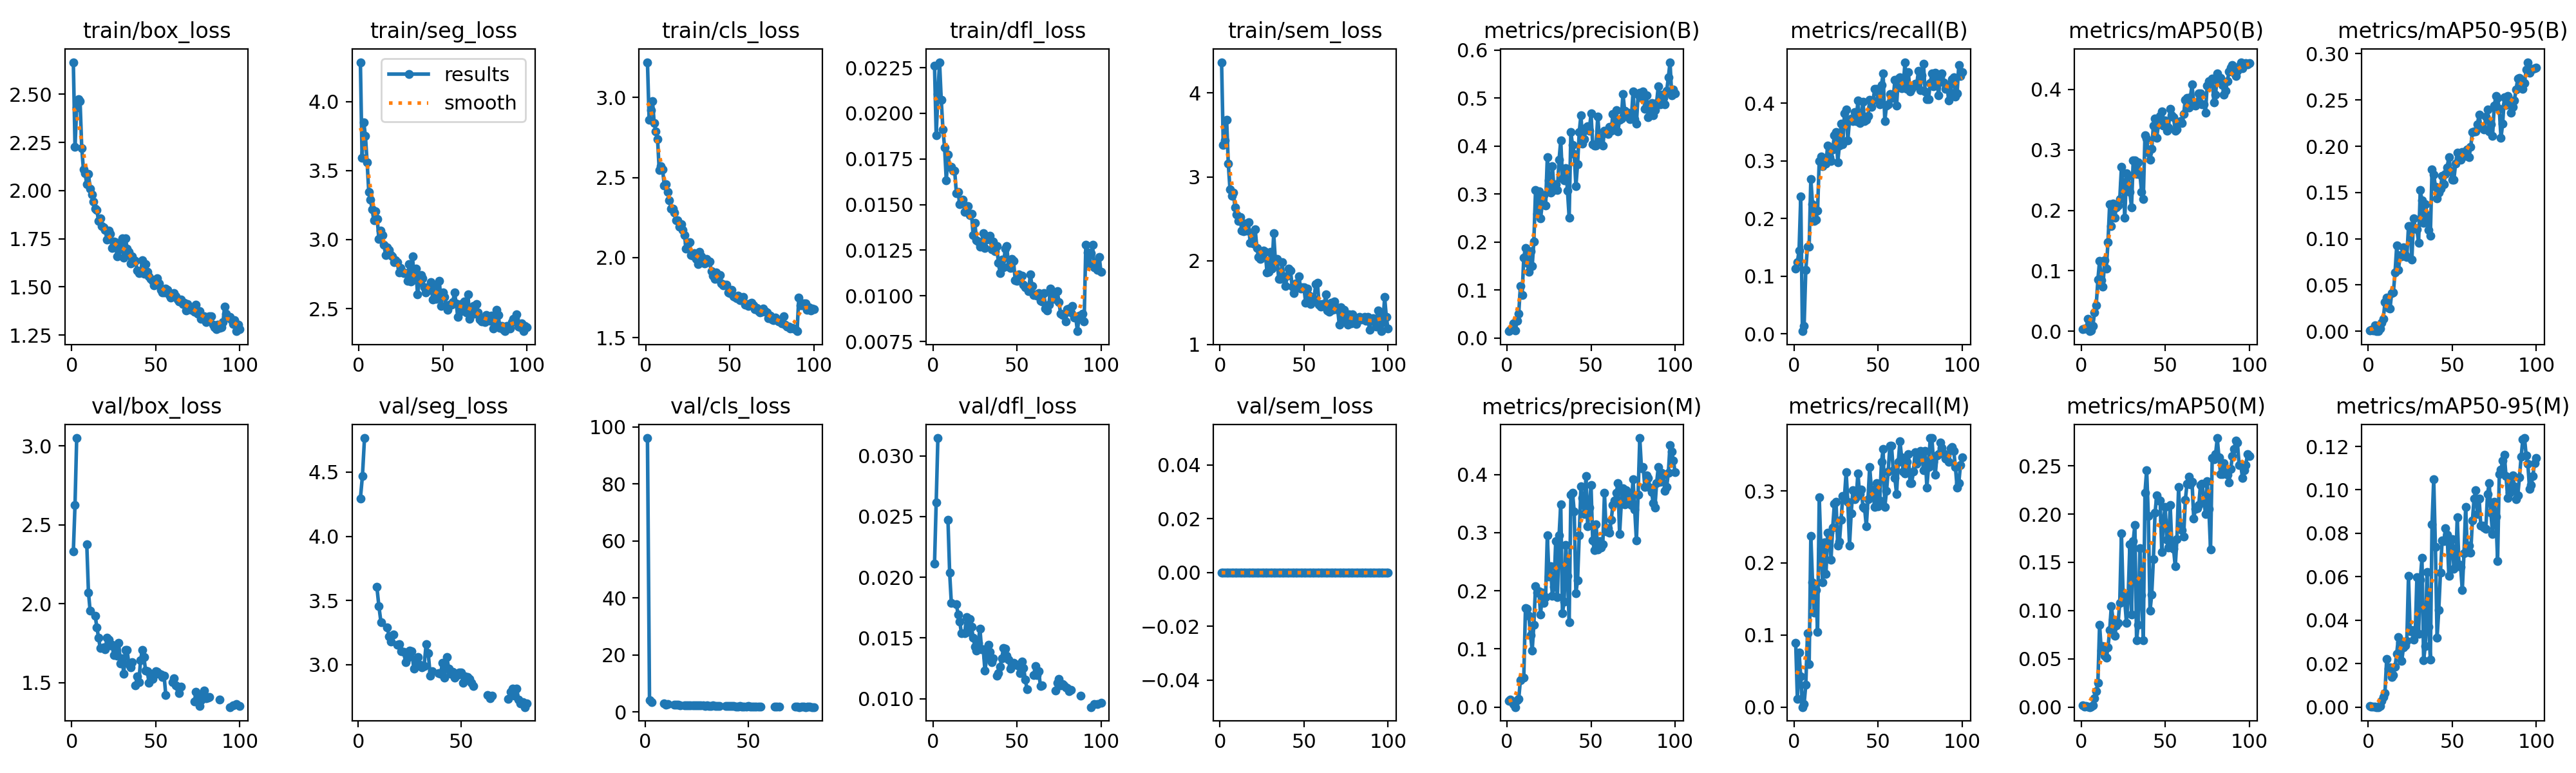

In [32]:
display(Image.open(RESULTS_IMAGE))

In [33]:
model = YOLO(str(MODEL_PATH))

## Predicted Mask Overlays

In [38]:
def overlay_masks(image, masks):
    image = image.convert("RGBA")
    if masks is None or len(masks) == 0:
        return image

    masks = 255 * masks.cpu().numpy().astype(np.uint8)
    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [tuple(int(c * 255) for c in cmap(i)[:3]) for i in range(n_masks)]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        if mask.size != image.size:
            mask = mask.resize(image.size, Image.Resampling.NEAREST)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image

predictions = model.predict(source=[str(p) for p in image_paths], conf=0.25, save=False, verbose=False)

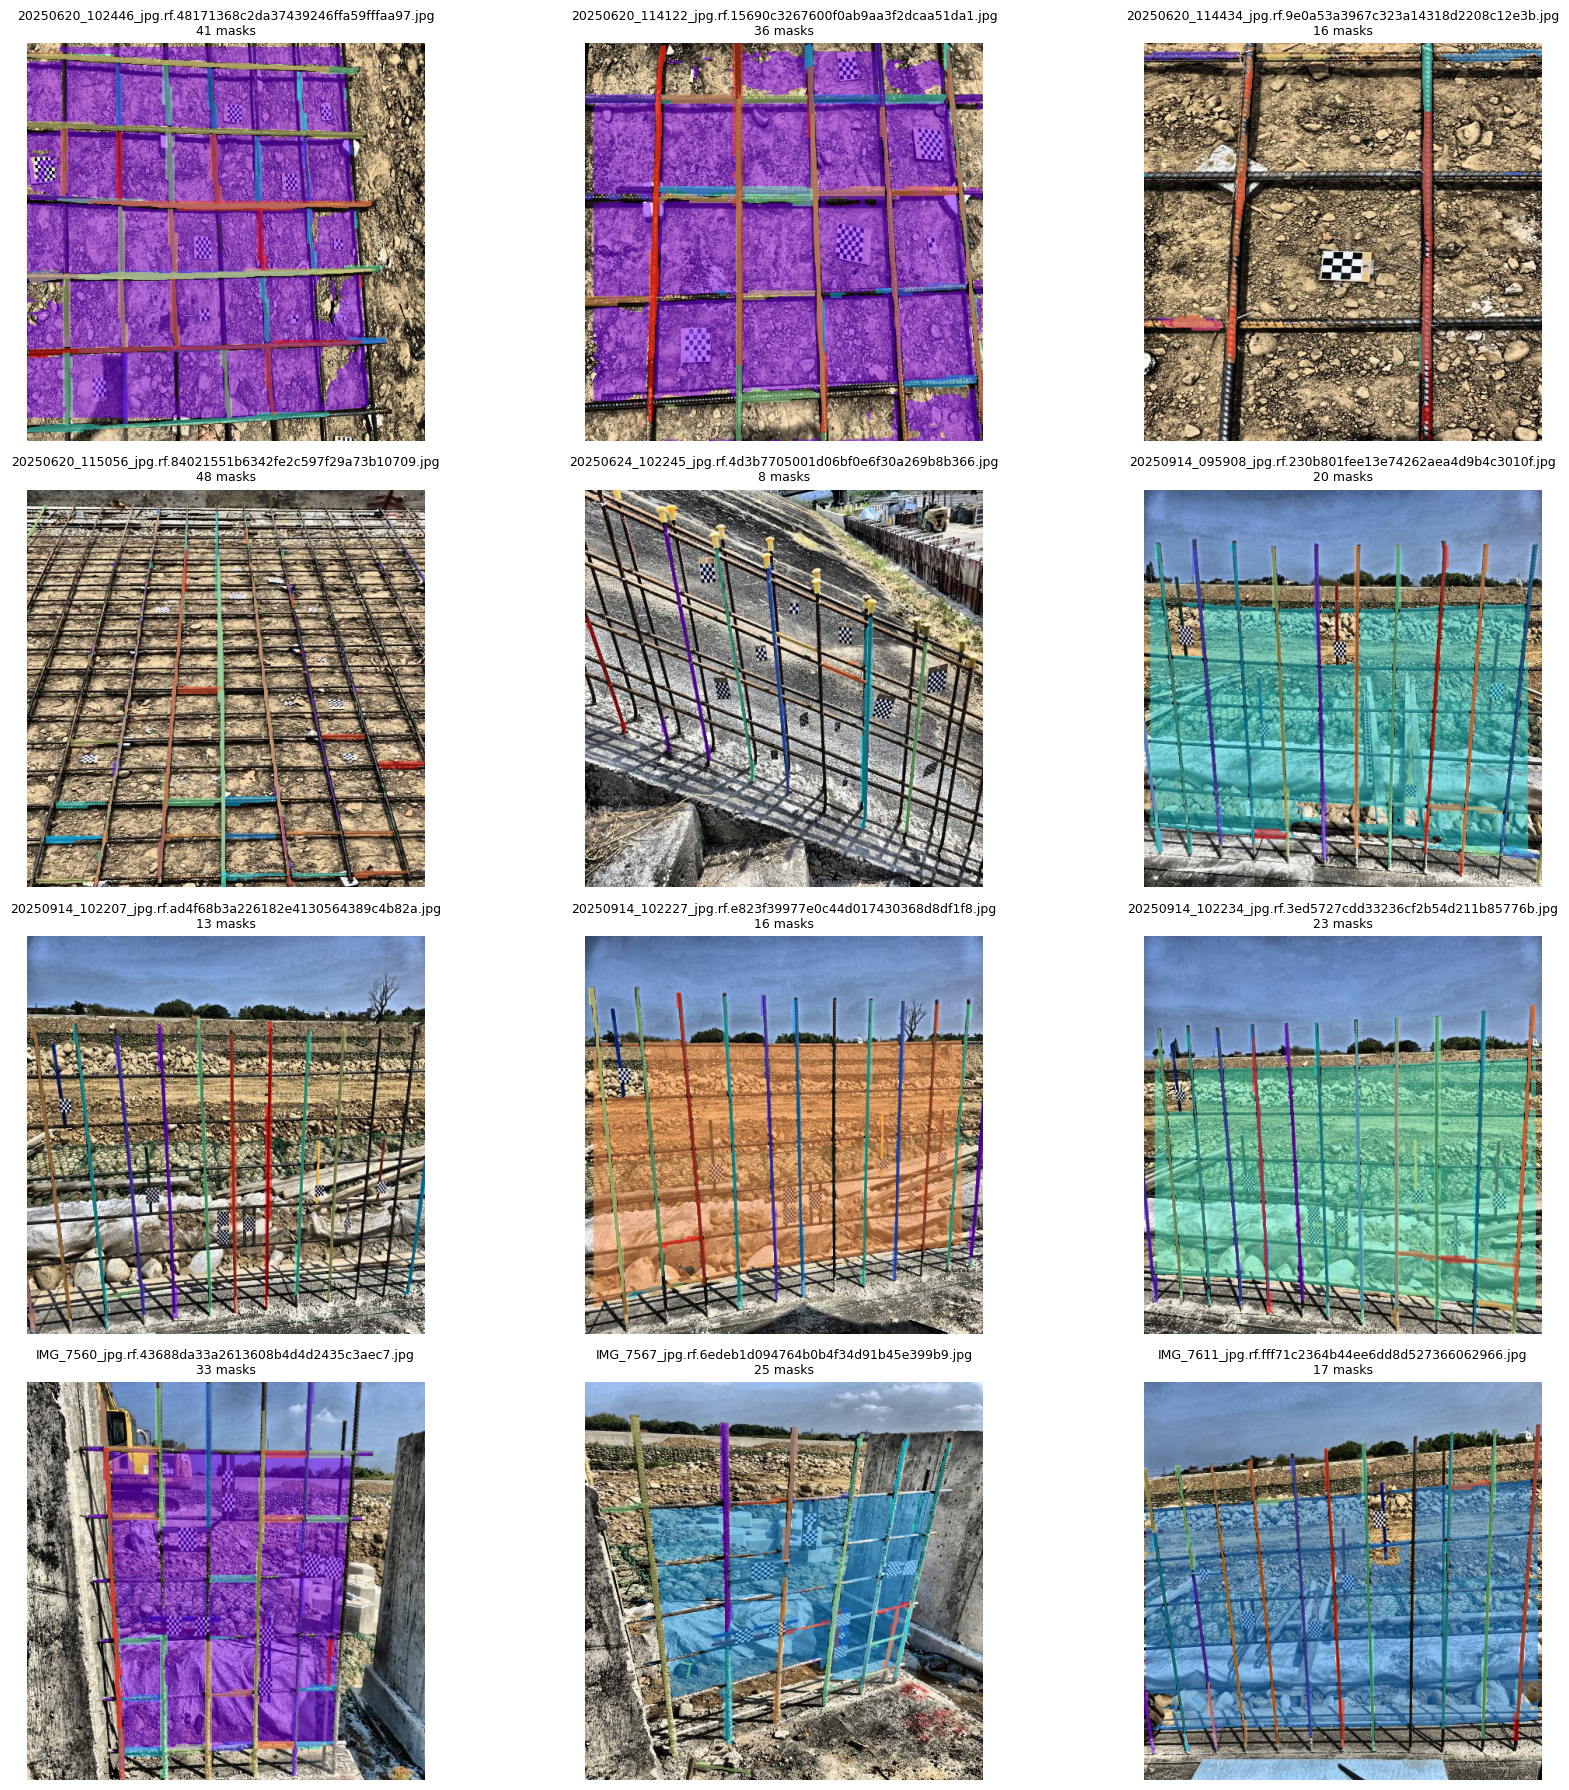

In [39]:
cols = 3
rows = int(np.ceil(len(predictions) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4.5))
axes = np.atleast_1d(axes).reshape(rows, cols)

for ax in axes.ravel():
    ax.axis("off")

for ax, result, image_path in zip(axes.ravel(), predictions, image_paths):
    image = Image.open(image_path)
    masks = result.masks.data if result.masks is not None else None
    overlay = overlay_masks(image, masks)
    mask_count = 0 if masks is None else len(masks)
    ax.imshow(overlay)
    ax.set_title(f"{image_path.name}\n{mask_count} masks", fontsize=9)
    ax.axis("off")

plt.tight_layout()
display(fig)
plt.close(fig)